# GeoPark Betsy Gun vs Hammer Source-Time-Function Analysis from Consensus Picks

This notebook compares the empirical source signatures of the GeoPark Betsy seisgun blast and repeated hammer blows using the event products from the detection/picking notebook.

The intended workflow is:

1. Load fixed-length event MiniSEED files.
2. Load station-level consensus pick times.
3. Assume the first valid event is the Betsy gun and all later valid events are hammer blows.
4. Align each trace by its station-specific consensus pick.
5. Compare Betsy and hammer waveforms and spectra station-by-station and component-by-component.
6. Optionally cross-correlate and stack hammer blows to estimate an empirical hammer source wavelet.
7. Export simple empirical source-time-function files that can be used as candidate SPECFEM source functions.

This notebook deliberately omits the event detection and picker-development logic. Those belong in the processing notebook that creates `GeoPark_station_consensus_picks.csv` and `event_*.mseed`.

## 1. Imports and configuration

Set `processed_dir` to the output folder created by the event-processing notebook. By default this assumes the cleaned notebook wrote:

```text
processed_geopark/events_mseed/event_000.mseed
processed_geopark/tables/geopark_station_consensus_picks.csv
```

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from scipy.signal import correlate, correlation_lags, welch

plt.rcParams["figure.dpi"] = 120

# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------
geopark_data_path = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark"
)

processed_dir = geopark_data_path / "processed_geopark"
event_mseed_dir = processed_dir / "events_mseed"
tables_dir = processed_dir / "tables"
figures_dir = processed_dir / "source_function_analysis"
stf_outdir = processed_dir / "empirical_source_time_functions"

station_picks_csv = tables_dir / "geopark_station_consensus_picks.csv"

for d in [figures_dir, stf_outdir]:
    d.mkdir(parents=True, exist_ok=True)

# Event/source classification rule.
# If betsy_event_idx is None, the notebook uses the first event_idx found in the event MiniSEED files.
betsy_event_idx = None

# Treat all other events as hammer blows.
exclude_event_indices = []

# Source-window settings around each station consensus pick.
# 0.25 s is enough for hammer impulses; Betsy can be longer, so we use a bit more by default.
pre_pick_s = 0.03
post_pick_s_hammer = 0.25
post_pick_s_betsy = 0.40

# Optional processing for waveform/spectral comparison.
analysis_filter = dict(freqmin=10.0, freqmax=150.0, corners=4, zerophase=True)
apply_filter = True
normalize_waveforms = True
normalize_spectra = True

# Cross-correlation stack settings for hammer blows.
cc_max_shift_s = 0.025       # do not allow absurd hammer shifts
cc_reference_strategy = "largest_peak"  # "first" or "largest_peak"

# Plot/export choices.
components = ["Z", "N", "E"]
station_names = [f"node{i}" for i in range(1, 7)]

print("processed_dir:", processed_dir)
print("event_mseed_dir:", event_mseed_dir)
print("station_picks_csv:", station_picks_csv)

processed_dir: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark
event_mseed_dir: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/events_mseed
station_picks_csv: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/tables/geopark_station_consensus_picks.csv


## 2. Utility functions

In [2]:
def event_idx_from_path(path):
    """Extract event index from filenames like event_003.mseed."""
    stem = Path(path).stem
    # Handles event_000, event_000_extra, etc.
    for token in stem.replace("-", "_").split("_"):
        if token.isdigit():
            return int(token)
    raise ValueError(f"Cannot infer event index from {path}")


def load_event_streams(event_mseed_dir):
    """Load event MiniSEED files into a dictionary: event_idx -> ObsPy Stream."""
    event_mseed_dir = Path(event_mseed_dir)
    files = sorted(event_mseed_dir.glob("event_*.mseed"))
    if not files:
        raise FileNotFoundError(f"No event_*.mseed files found in {event_mseed_dir}")

    event_streams = {}
    for path in files:
        event_idx = event_idx_from_path(path)
        st = obspy.read(str(path))
        st.merge(method=1, fill_value="interpolate")
        event_streams[event_idx] = st
    return event_streams


def to_utcdatetime(value):
    """Robust conversion from CSV/string/pandas/UTCDateTime to ObsPy UTCDateTime."""
    if value is None:
        return None
    if isinstance(value, obspy.UTCDateTime):
        return value
    if pd.isna(value):
        return None
    text = str(value)
    if text in ("None", "NaT", "nan", ""):
        return None
    return obspy.UTCDateTime(text)


def preprocess_trace(tr, apply_filter=True, filter_kwargs=None):
    """Return a lightly processed trace for waveform/spectrum comparison."""
    tr2 = tr.copy()
    tr2.detrend("demean")
    tr2.detrend("linear")
    tr2.taper(max_percentage=0.02)
    if apply_filter and filter_kwargs:
        tr2.filter("bandpass", **filter_kwargs)
    return tr2


def trim_trace_around_pick(tr, pick_time, pre_s=0.03, post_s=0.25, apply_filter=True, filter_kwargs=None):
    """
    Trim a trace around a station consensus pick.

    Returns a processed trace whose time axis should be interpreted relative to pick time.
    """
    pick_time = to_utcdatetime(pick_time)
    if pick_time is None:
        return None
    trw = tr.copy().trim(pick_time - pre_s, pick_time + post_s, pad=True, fill_value=0)
    return preprocess_trace(trw, apply_filter=apply_filter, filter_kwargs=filter_kwargs)


def trace_relative_time(tr, zero_time):
    """Time axis in seconds relative to zero_time."""
    zero_time = to_utcdatetime(zero_time)
    return np.arange(tr.stats.npts) * tr.stats.delta + (tr.stats.starttime - zero_time)


def normalized_data(tr):
    """Median-demeaned trace data, normalized by max absolute amplitude."""
    y = tr.data.astype(float)
    y = y - np.nanmedian(y)
    m = np.nanmax(np.abs(y))
    if m > 0:
        y = y / m
    return y


def amplitude_spectrum_from_array(y, dt, taper_fraction=0.05, normalize=False):
    """Return one-sided FFT amplitude spectrum for a 1-D array."""
    y = np.asarray(y, dtype=float)
    y = y - np.nanmedian(y)
    n = len(y)
    if n < 2:
        return np.array([]), np.array([])
    ntaper = int(taper_fraction * n)
    if ntaper > 1:
        taper = np.ones(n)
        ramp = np.hanning(2 * ntaper)
        taper[:ntaper] = ramp[:ntaper]
        taper[-ntaper:] = ramp[-ntaper:]
        y = y * taper
    freqs = np.fft.rfftfreq(n, dt)
    amp = np.abs(np.fft.rfft(y))
    if normalize and amp.max() > 0:
        amp = amp / amp.max()
    return freqs, amp


def amplitude_spectrum(tr, taper_fraction=0.05, normalize=False):
    return amplitude_spectrum_from_array(tr.data.astype(float), tr.stats.delta, taper_fraction=taper_fraction, normalize=normalize)


def get_station_pick(station_picks_df, event_idx, station):
    """Return the station consensus pick time for one event/station, or None."""
    rows = station_picks_df[
        (station_picks_df["event_idx"] == event_idx)
        & (station_picks_df["station"].astype(str) == str(station))
        & (station_picks_df["consensus_ok"] == True)
    ]
    if len(rows) == 0:
        return None
    return to_utcdatetime(rows.iloc[0]["consensus_time"])


def get_trace_for_station_component(st_event, station, component):
    """Return first trace matching station and component, or None."""
    traces = st_event.select(station=str(station), component=str(component))
    if len(traces) == 0:
        return None
    return traces[0]

## 3. Load event MiniSEED files and consensus picks

In [3]:
event_streams = load_event_streams(event_mseed_dir)
station_picks_df = pd.read_csv(station_picks_csv)

# Normalize event_idx type.
station_picks_df["event_idx"] = station_picks_df["event_idx"].astype(int)

available_event_indices = sorted(event_streams.keys())
print(f"Loaded {len(event_streams)} event streams")
print("Available event indices:", available_event_indices[:20], "..." if len(available_event_indices) > 20 else "")

print("Consensus picks:")
display(station_picks_df.head())

Loaded 56 event streams
Available event indices: [0, 4, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 25, 26] ...
Consensus picks:


,event_idx,station,event_on_time,event_off_time,consensus_ok,consensus_time,consensus_relative_s,consensus_n_votes,consensus_methods,consensus_components,ar_p_time,ar_s_time,ar_p_relative_s,ar_s_relative_s
0,0,node1,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.320000Z,0.034,3,"baer,baer,baer","N,E,Z",2026-04-30T18:30:06.884000Z,2026-04-30T18:30:06.894000Z,0.598,0.608
1,0,node2,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.900000Z,0.614,5,"ar_p,aic,aic,aic,baer","ZNE,Z,N,E,E",2026-04-30T18:30:06.894000Z,2026-04-30T18:30:06.900000Z,0.608,0.614
2,0,node3,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.906000Z,0.620,5,"ar_p,baer,aic,aic,aic","ZNE,N,Z,N,E",2026-04-30T18:30:06.894000Z,2026-04-30T18:30:06.910000Z,0.608,0.624
3,0,node4,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.910000Z,0.624,5,"ar_p,aic,aic,aic,baer","ZNE,Z,N,E,Z",2026-04-30T18:30:06.898000Z,2026-04-30T18:30:06.910000Z,0.612,0.624
4,0,node5,2026-04-30 18:30:06.536,2026-04-30 18:30:07.084,True,2026-04-30T18:30:06.916000Z,0.630,7,"ar_p,aic,baer,aic,baer,baer,aic","ZNE,Z,Z,N,N,E,E",2026-04-30T18:30:06.902000Z,2026-04-30T18:30:06.286000Z,0.616,0.000


## 4. Classify first event as Betsy and remaining events as hammer blows

This follows the field assumption: the first triggered event is the Betsy gun, and the remaining events are hammer blows. Adjust `betsy_event_idx` or `exclude_event_indices` in the configuration if needed.

In [4]:
valid_event_indices = sorted(set(available_event_indices) - set(exclude_event_indices))

if betsy_event_idx is None:
    betsy_event_idx = valid_event_indices[0]

hammer_event_indices = [idx for idx in valid_event_indices if idx != betsy_event_idx]

print("Betsy event:", betsy_event_idx)
print("Number of hammer events:", len(hammer_event_indices))
print("First few hammer events:", hammer_event_indices[:10])

source_labels = pd.DataFrame({
    "event_idx": valid_event_indices,
    "source_type": ["betsy" if idx == betsy_event_idx else "hammer" for idx in valid_event_indices],
})
source_labels.to_csv(tables_dir / "geopark_source_labels_betsy_hammer.csv", index=False)
display(source_labels.head())

Betsy event: 0
Number of hammer events: 55
First few hammer events: [4, 6, 7, 8, 9, 10, 11, 13, 14, 15]


,event_idx,source_type
0,0,betsy
1,4,hammer
2,6,hammer
3,7,hammer
4,8,hammer


## 5. Build aligned pick-window traces

For each event/station/component, we trim around that station's own consensus pick. This avoids using a single event-wide time origin and is better for source-function comparison because each station is aligned on its own observed first arrival.

In [5]:
def build_aligned_trace_table(
    event_streams,
    station_picks_df,
    betsy_event_idx,
    hammer_event_indices,
    station_names,
    components=("Z", "N", "E"),
    pre_pick_s=0.03,
    post_pick_s_hammer=0.25,
    post_pick_s_betsy=0.40,
    apply_filter=True,
    filter_kwargs=None,
):
    """
    Create a table of aligned traces keyed by event/station/component.

    The trace objects are stored in a DataFrame object column for interactive analysis.
    """
    rows = []

    all_indices = [betsy_event_idx] + list(hammer_event_indices)
    for event_idx in all_indices:
        if event_idx not in event_streams:
            continue

        source_type = "betsy" if event_idx == betsy_event_idx else "hammer"
        post_s = post_pick_s_betsy if source_type == "betsy" else post_pick_s_hammer
        st_event = event_streams[event_idx]

        for station in station_names:
            pick_time = get_station_pick(station_picks_df, event_idx, station)
            if pick_time is None:
                continue

            for component in components:
                tr = get_trace_for_station_component(st_event, station, component)
                if tr is None:
                    continue

                tr_aligned = trim_trace_around_pick(
                    tr,
                    pick_time,
                    pre_s=pre_pick_s,
                    post_s=post_s,
                    apply_filter=apply_filter,
                    filter_kwargs=filter_kwargs,
                )

                rows.append({
                    "event_idx": event_idx,
                    "source_type": source_type,
                    "station": station,
                    "component": component,
                    "pick_time": pick_time,
                    "pre_pick_s": pre_pick_s,
                    "post_pick_s": post_s,
                    "trace_id": tr.id,
                    "sampling_rate": tr.stats.sampling_rate,
                    "npts": tr_aligned.stats.npts if tr_aligned else None,
                    "trace": tr_aligned,
                })

    return pd.DataFrame(rows)


aligned_df = build_aligned_trace_table(
    event_streams,
    station_picks_df,
    betsy_event_idx=betsy_event_idx,
    hammer_event_indices=hammer_event_indices,
    station_names=station_names,
    components=components,
    pre_pick_s=pre_pick_s,
    post_pick_s_hammer=post_pick_s_hammer,
    post_pick_s_betsy=post_pick_s_betsy,
    apply_filter=apply_filter,
    filter_kwargs=analysis_filter,
)

print(aligned_df.shape)
display(aligned_df.drop(columns=["trace"]).head())

aligned_df.drop(columns=["trace"]).to_csv(tables_dir / "geopark_aligned_source_trace_index.csv", index=False)

(1008, 11)


,event_idx,source_type,station,component,pick_time,pre_pick_s,post_pick_s,trace_id,sampling_rate,npts
0,0,betsy,node1,Z,2026-04-30T18:30:06.320000Z,0.03,0.4,SS.node1.SW.DPZ,500.0,216
1,0,betsy,node1,N,2026-04-30T18:30:06.320000Z,0.03,0.4,SS.node1.SW.DPN,500.0,216
2,0,betsy,node1,E,2026-04-30T18:30:06.320000Z,0.03,0.4,SS.node1.SW.DPE,500.0,216
3,0,betsy,node2,Z,2026-04-30T18:30:06.900000Z,0.03,0.4,SS.node2.SW.DPZ,500.0,216
4,0,betsy,node2,N,2026-04-30T18:30:06.900000Z,0.03,0.4,SS.node2.SW.DPN,500.0,216


## 6. Waveform comparison: Betsy vs all hammer blows

Each panel overlays the Betsy trace and all hammer traces for one station/component, aligned to the station-specific consensus pick at `t = 0`.

In [6]:
def plot_betsy_vs_hammer_waveforms(
    aligned_df,
    station,
    component="Z",
    normalize=True,
    hammer_alpha=0.25,
    outfile=None,
    dpi=180,
):
    sub = aligned_df[(aligned_df["station"] == station) & (aligned_df["component"] == component)]
    betsy = sub[sub["source_type"] == "betsy"]
    hammer = sub[sub["source_type"] == "hammer"]

    if len(sub) == 0:
        print(f"No aligned traces for {station} {component}")
        return None

    fig, ax = plt.subplots(figsize=(11, 5))

    # Hammers: thin grey overlay.
    for _, row in hammer.iterrows():
        tr = row["trace"]
        t = trace_relative_time(tr, row["pick_time"])
        y = normalized_data(tr) if normalize else tr.data.astype(float)
        ax.plot(t, y, color="0.65", alpha=hammer_alpha, linewidth=0.8)

    # Hammer median stack if available.
    stack_t, stack_y, nstack = stack_traces_simple(hammer, normalize=normalize)
    if stack_t is not None:
        ax.plot(stack_t, stack_y, color="black", linewidth=2.0, label=f"Hammer stack, n={nstack}")

    # Betsy: red.
    for i, (_, row) in enumerate(betsy.iterrows()):
        tr = row["trace"]
        t = trace_relative_time(tr, row["pick_time"])
        y = normalized_data(tr) if normalize else tr.data.astype(float)
        ax.plot(t, y, color="red", linewidth=2.0, label="Betsy" if i == 0 else None)

    ax.axvline(0, color="orange", linewidth=1.5, linestyle="--", label="consensus pick")
    ax.set_title(f"Betsy vs hammer waveforms: {station} {component}")
    ax.set_xlabel("Time from station consensus pick [s]")
    ax.set_ylabel("Normalized amplitude" if normalize else "Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)
        plt.close(fig)
    return fig


def stack_traces_simple(rows, normalize=True):
    """
    Simple sample-by-sample median stack of aligned traces in a DataFrame subset.

    This assumes traces are already cut to the same pre/post pick window and sample rate.
    Uses the shortest trace length to avoid padding issues.
    """
    if len(rows) == 0:
        return None, None, 0
    traces = list(rows["trace"])
    picks = list(rows["pick_time"])
    npts = min(tr.stats.npts for tr in traces)
    if npts < 2:
        return None, None, 0
    sr = traces[0].stats.sampling_rate
    data = []
    for tr in traces:
        y = normalized_data(tr) if normalize else tr.data.astype(float)
        data.append(y[:npts])
    data = np.vstack(data)
    stack = np.nanmedian(data, axis=0)
    # For our aligned trims, time relative to pick is approximately -pre_pick_s + sample*dt.
    t = np.arange(npts) / sr - float(rows.iloc[0]["pre_pick_s"])
    return t, stack, len(traces)


# Generate compact figures for every station/component.
waveform_fig_dir = figures_dir / "betsy_vs_hammer_waveforms"
waveform_fig_dir.mkdir(parents=True, exist_ok=True)

for station in station_names:
    for component in components:
        plot_betsy_vs_hammer_waveforms(
            aligned_df,
            station,
            component=component,
            normalize=normalize_waveforms,
            outfile=waveform_fig_dir / f"{station}_{component}_betsy_vs_hammer_waveforms.png",
        )

print(f"Wrote waveform figures to {waveform_fig_dir}")

Wrote waveform figures to /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/source_function_analysis/betsy_vs_hammer_waveforms


## 7. Spectral comparison

This compares the Betsy spectrum with the median hammer-stack spectrum for each station/component. The hammer stack is useful because individual hammer blows may vary in amplitude and timing, but their shared spectral shape should be more stable after alignment.

In [7]:
def plot_betsy_vs_hammer_spectra(
    aligned_df,
    station,
    component="Z",
    fmin=0,
    fmax=250,
    normalize=True,
    outfile=None,
    dpi=180,
):
    sub = aligned_df[(aligned_df["station"] == station) & (aligned_df["component"] == component)]
    betsy = sub[sub["source_type"] == "betsy"]
    hammer = sub[sub["source_type"] == "hammer"]

    if len(sub) == 0:
        print(f"No aligned traces for {station} {component}")
        return None

    fig, ax = plt.subplots(figsize=(10, 5))

    # Hammer individual spectra, faint.
    for _, row in hammer.iterrows():
        tr = row["trace"]
        f, a = amplitude_spectrum(tr, normalize=normalize)
        mask = (f >= fmin) & (f <= fmax)
        ax.plot(f[mask], a[mask], color="0.75", alpha=0.25, linewidth=0.8)

    # Hammer stack spectrum.
    stack_t, stack_y, nstack = stack_traces_simple(hammer, normalize=normalize_waveforms)
    if stack_y is not None:
        dt = 1.0 / float(hammer.iloc[0]["sampling_rate"])
        f, a = amplitude_spectrum_from_array(stack_y, dt, normalize=normalize)
        mask = (f >= fmin) & (f <= fmax)
        ax.plot(f[mask], a[mask], color="black", linewidth=2.0, label=f"Hammer stack, n={nstack}")

    # Betsy spectrum.
    for i, (_, row) in enumerate(betsy.iterrows()):
        tr = row["trace"]
        f, a = amplitude_spectrum(tr, normalize=normalize)
        mask = (f >= fmin) & (f <= fmax)
        ax.plot(f[mask], a[mask], color="red", linewidth=2.0, label="Betsy" if i == 0 else None)

    ax.set_title(f"Betsy vs hammer spectra: {station} {component}")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Normalized amplitude" if normalize else "Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)
        plt.close(fig)
    return fig


spectra_fig_dir = figures_dir / "betsy_vs_hammer_spectra"
spectra_fig_dir.mkdir(parents=True, exist_ok=True)

for station in station_names:
    for component in components:
        plot_betsy_vs_hammer_spectra(
            aligned_df,
            station,
            component=component,
            fmin=0,
            fmax=250,
            normalize=normalize_spectra,
            outfile=spectra_fig_dir / f"{station}_{component}_betsy_vs_hammer_spectra.png",
        )

print(f"Wrote spectral figures to {spectra_fig_dir}")

Wrote spectral figures to /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/source_function_analysis/betsy_vs_hammer_spectra


## 8. Summary panel for the closest station

The nearest station often gives the closest approximation to the source wavelet, because propagation and scattering effects are shortest. Adjust `closest_station` after inspecting the geometry if needed.

PosixPath('/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/source_function_analysis/node1_betsy_hammer_summary_panel.png')

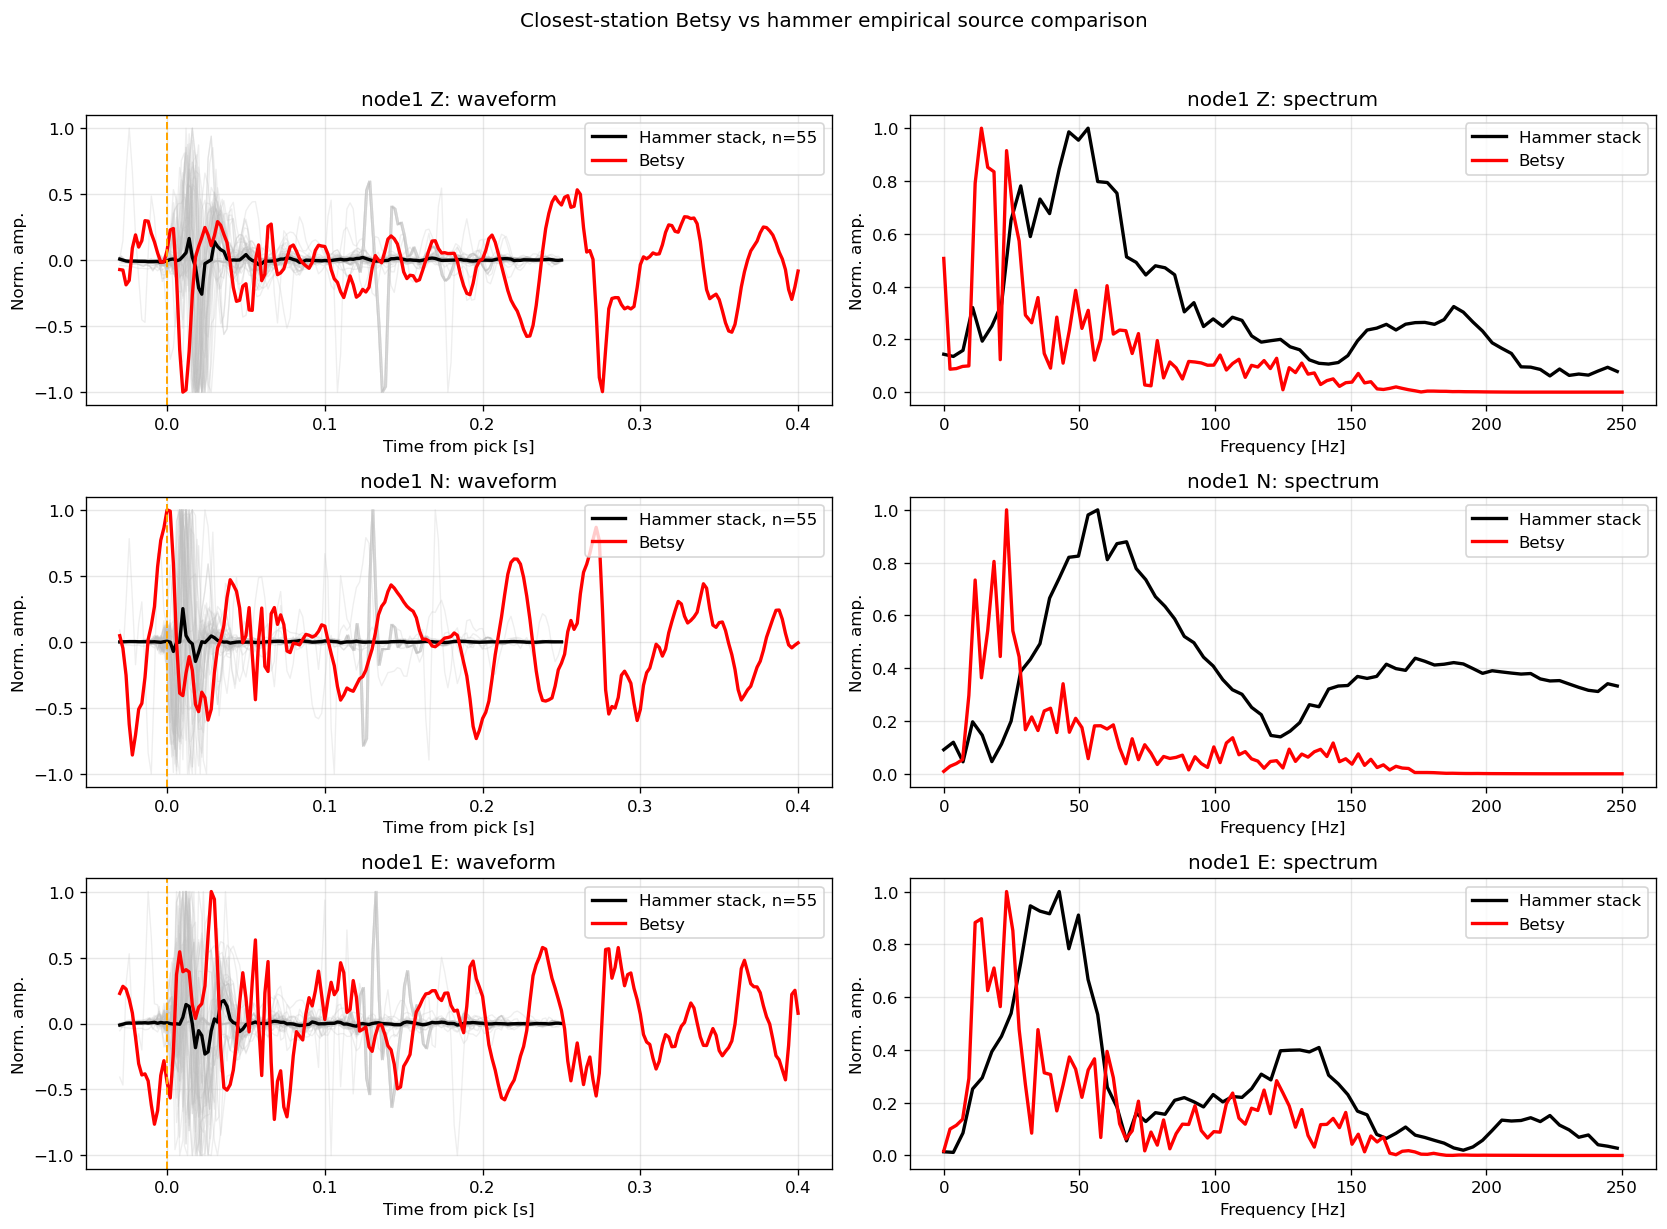

In [8]:
closest_station = "node1"

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for row_i, component in enumerate(components):
    # Waveform panel.
    ax = axes[row_i, 0]
    sub = aligned_df[(aligned_df["station"] == closest_station) & (aligned_df["component"] == component)]
    betsy = sub[sub["source_type"] == "betsy"]
    hammer = sub[sub["source_type"] == "hammer"]

    for _, r in hammer.iterrows():
        tr = r["trace"]
        ax.plot(trace_relative_time(tr, r["pick_time"]), normalized_data(tr), color="0.75", alpha=0.25, linewidth=0.8)

    stack_t, stack_y, nstack = stack_traces_simple(hammer, normalize=True)
    if stack_y is not None:
        ax.plot(stack_t, stack_y, color="black", linewidth=2, label=f"Hammer stack, n={nstack}")

    for i, (_, r) in enumerate(betsy.iterrows()):
        tr = r["trace"]
        ax.plot(trace_relative_time(tr, r["pick_time"]), normalized_data(tr), color="red", linewidth=2, label="Betsy" if i == 0 else None)

    ax.axvline(0, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"{closest_station} {component}: waveform")
    ax.set_xlabel("Time from pick [s]")
    ax.set_ylabel("Norm. amp.")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    # Spectrum panel.
    ax = axes[row_i, 1]
    if stack_y is not None:
        dt = 1.0 / float(hammer.iloc[0]["sampling_rate"])
        f, a = amplitude_spectrum_from_array(stack_y, dt, normalize=True)
        mask = (f >= 0) & (f <= 250)
        ax.plot(f[mask], a[mask], color="black", linewidth=2, label="Hammer stack")

    for i, (_, r) in enumerate(betsy.iterrows()):
        f, a = amplitude_spectrum(r["trace"], normalize=True)
        mask = (f >= 0) & (f <= 250)
        ax.plot(f[mask], a[mask], color="red", linewidth=2, label="Betsy" if i == 0 else None)

    ax.set_title(f"{closest_station} {component}: spectrum")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Norm. amp.")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

fig.suptitle("Closest-station Betsy vs hammer empirical source comparison", y=1.02)
fig.tight_layout()
summary_file = figures_dir / f"{closest_station}_betsy_hammer_summary_panel.png"
fig.savefig(summary_file, dpi=180, bbox_inches="tight")
summary_file

## 9. Stretch goal: cross-correlation alignment and hammer stack

The previous stack uses consensus-pick alignment only. This section improves the hammer stack by cross-correlating each hammer trace against a reference hammer trace for the same station/component. Use this only after the basic consensus-pick figures look sensible.

In [9]:
def choose_reference_trace(rows, strategy="largest_peak"):
    """Choose a reference trace row for cross-correlation stacking."""
    if len(rows) == 0:
        return None
    if strategy == "first":
        return rows.iloc[0]
    if strategy == "largest_peak":
        peaks = []
        for _, row in rows.iterrows():
            y = row["trace"].data.astype(float)
            peaks.append(np.nanmax(np.abs(y)))
        return rows.iloc[int(np.argmax(peaks))]
    raise ValueError("strategy must be 'first' or 'largest_peak'")


def shift_array_by_samples(y, shift_samples):
    """
    Shift array by integer samples using zero padding.

    Positive shift moves the signal later. Negative shift moves it earlier.
    """
    y = np.asarray(y)
    out = np.zeros_like(y)
    if shift_samples == 0:
        return y.copy()
    if shift_samples > 0:
        out[shift_samples:] = y[:-shift_samples]
    else:
        out[:shift_samples] = y[-shift_samples:]
    return out


def cc_align_and_stack_hammers(
    aligned_df,
    station,
    component="Z",
    max_shift_s=0.025,
    reference_strategy="largest_peak",
    normalize=True,
):
    """Cross-correlate hammer traces for one station/component and return stack info."""
    rows = aligned_df[
        (aligned_df["station"] == station)
        & (aligned_df["component"] == component)
        & (aligned_df["source_type"] == "hammer")
    ].copy()

    if len(rows) == 0:
        return None

    ref_row = choose_reference_trace(rows, strategy=reference_strategy)
    ref = ref_row["trace"]
    sr = ref.stats.sampling_rate
    max_shift_samples = int(round(max_shift_s * sr))
    npts = min(tr.stats.npts for tr in rows["trace"])

    yref = normalized_data(ref)[:npts] if normalize else ref.data.astype(float)[:npts]
    aligned = []
    shift_rows = []

    for _, row in rows.iterrows():
        tr = row["trace"]
        y = normalized_data(tr)[:npts] if normalize else tr.data.astype(float)[:npts]

        cc = correlate(y, yref, mode="full")
        lags = correlation_lags(len(y), len(yref), mode="full")
        keep = np.abs(lags) <= max_shift_samples
        lag = int(lags[keep][np.argmax(cc[keep])])

        # If y lags ref by +lag samples in correlation convention, shift by -lag to align to reference.
        y_shifted = shift_array_by_samples(y, -lag)
        aligned.append(y_shifted)

        shift_rows.append({
            "event_idx": row["event_idx"],
            "station": station,
            "component": component,
            "lag_samples": lag,
            "shift_applied_samples": -lag,
            "shift_applied_s": -lag / sr,
            "cc_max": float(np.max(cc[keep])) if np.any(keep) else np.nan,
        })

    aligned = np.vstack(aligned)
    stack = np.nanmedian(aligned, axis=0)
    t = np.arange(npts) / sr - float(rows.iloc[0]["pre_pick_s"])

    return {
        "t": t,
        "stack": stack,
        "aligned_data": aligned,
        "shifts": pd.DataFrame(shift_rows),
        "reference_event_idx": int(ref_row["event_idx"]),
        "n": len(rows),
        "sampling_rate": sr,
    }


def plot_cc_hammer_stack(aligned_df, station, component="Z", outfile=None, dpi=180):
    result = cc_align_and_stack_hammers(
        aligned_df,
        station,
        component=component,
        max_shift_s=cc_max_shift_s,
        reference_strategy=cc_reference_strategy,
        normalize=True,
    )
    if result is None:
        print(f"No hammer traces for {station} {component}")
        return None, None

    fig, axes = plt.subplots(2, 1, figsize=(11, 8))
    ax = axes[0]
    for y in result["aligned_data"]:
        ax.plot(result["t"], y, color="0.7", alpha=0.25, linewidth=0.8)
    ax.plot(result["t"], result["stack"], color="black", linewidth=2.2, label=f"CC hammer stack, n={result['n']}")
    ax.axvline(0, color="orange", linestyle="--", linewidth=1.2)
    ax.set_title(f"Cross-correlation-aligned hammer stack: {station} {component}")
    ax.set_xlabel("Time from pick [s]")
    ax.set_ylabel("Normalized amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    ax = axes[1]
    f, a = amplitude_spectrum_from_array(result["stack"], 1 / result["sampling_rate"], normalize=True)
    mask = (f >= 0) & (f <= 250)
    ax.plot(f[mask], a[mask], color="black", linewidth=2)
    ax.set_title("Hammer stack spectrum")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Normalized amplitude")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)
        plt.close(fig)
    return fig, result


cc_fig_dir = figures_dir / "hammer_cc_stacks"
cc_fig_dir.mkdir(parents=True, exist_ok=True)

all_shift_tables = []
cc_results = {}
for station in station_names:
    for component in components:
        fig, result = plot_cc_hammer_stack(
            aligned_df,
            station,
            component=component,
            outfile=cc_fig_dir / f"{station}_{component}_hammer_cc_stack.png",
        )
        if result is not None:
            cc_results[(station, component)] = result
            all_shift_tables.append(result["shifts"])

if all_shift_tables:
    hammer_shift_df = pd.concat(all_shift_tables, ignore_index=True)
    hammer_shift_df.to_csv(tables_dir / "geopark_hammer_cc_shifts.csv", index=False)
    display(hammer_shift_df.head())

print(f"Wrote CC hammer stack figures to {cc_fig_dir}")

,event_idx,station,component,lag_samples,shift_applied_samples,shift_applied_s,cc_max
0,4,node1,Z,-9,9,0.018,0.307968
1,6,node1,Z,-6,6,0.012,2.501639
2,7,node1,Z,-12,12,0.024,1.622744
3,8,node1,Z,0,0,0.000,1.696560
4,9,node1,Z,-2,2,0.004,2.956575


Wrote CC hammer stack figures to /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/source_function_analysis/hammer_cc_stacks


## 10. Export empirical source-time functions

This exports simple text/CSV source-time functions for the closest station. These are *not* true deconvolved source functions; they are empirical near-source waveforms and should be treated as candidate modelling wavelets.

For SPECFEM, you may later want to resample, taper, remove mean, and choose whether to use the raw velocity-like trace, differentiated trace, or force-like approximation depending on the source implementation.

In [10]:
def export_stf_csv(t, y, outfile, label="source"):
    outfile = Path(outfile)
    outfile.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame({"time_s": t, "amplitude": y})
    df.to_csv(outfile, index=False)
    return outfile

# Export closest-station Z by default.
export_station = closest_station
export_component = "Z"

# Betsy empirical trace.
betsy_rows = aligned_df[
    (aligned_df["station"] == export_station)
    & (aligned_df["component"] == export_component)
    & (aligned_df["source_type"] == "betsy")
]

if len(betsy_rows):
    row = betsy_rows.iloc[0]
    tr = row["trace"]
    t_betsy = trace_relative_time(tr, row["pick_time"])
    y_betsy = normalized_data(tr)
    betsy_file = export_stf_csv(
        t_betsy,
        y_betsy,
        stf_outdir / f"betsy_empirical_{export_station}_{export_component}.csv",
        label="betsy",
    )
    print("Wrote", betsy_file)

# Hammer consensus-pick stack.
hammer_rows = aligned_df[
    (aligned_df["station"] == export_station)
    & (aligned_df["component"] == export_component)
    & (aligned_df["source_type"] == "hammer")
]

t_hammer, y_hammer, n_hammer = stack_traces_simple(hammer_rows, normalize=True)
if y_hammer is not None:
    hammer_file = export_stf_csv(
        t_hammer,
        y_hammer,
        stf_outdir / f"hammer_pick_aligned_stack_{export_station}_{export_component}.csv",
        label="hammer_pick_stack",
    )
    print("Wrote", hammer_file)

# Hammer cross-correlation stack if available.
cc_key = (export_station, export_component)
if cc_key in cc_results:
    result = cc_results[cc_key]
    hammer_cc_file = export_stf_csv(
        result["t"],
        result["stack"],
        stf_outdir / f"hammer_cc_stack_{export_station}_{export_component}.csv",
        label="hammer_cc_stack",
    )
    print("Wrote", hammer_cc_file)

Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/empirical_source_time_functions/betsy_empirical_node1_Z.csv
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/empirical_source_time_functions/hammer_pick_aligned_stack_node1_Z.csv
Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/processed_geopark/empirical_source_time_functions/hammer_cc_stack_node1_Z.csv


## 11. Interpretation notes

Recommended checks before using these as source wavelets:

1. Confirm event classification: verify the first event is indeed the Betsy gun.
2. Check station dependence: if the closest station has clipping, use the next station instead.
3. Compare Z/N/E components: a vertical hammer blow may be clearest on Z, but coupling and plate ringing can appear on all components.
4. Prefer the hammer cross-correlation stack only if the shift table shows small, physically reasonable shifts.
5. Do not over-interpret these as true source functions: they include path, site, coupling, and instrument effects.

For modelling, the practical value is that these empirical wavelets are much better constrained than arbitrary Ricker/Gaussian guesses.